# 🎬 Recommender — Collaborative Filtering EDA
## Exploratory Data Analysis (EDA)

> Dataset berisi rating pengguna terhadap item (skala 1–5) untuk sistem rekomendasi *collaborative filtering*.
> Dataset tetap dari file CSV agar hasilnya **identik** di VS Code maupun Google Colab.

In [1]:
"""SETUP — Wajib dijalankan sekali."""
import os
import sys

# Deteksi lingkungan Colab
IN_COLAB = "google.colab" in sys.modules

print(f"In Google Colab: {IN_COLAB}")
print(f"Working Dir : {os.getcwd()}")

# --- Klona repo bila diperlukan (agar impor internal berfungsi) ---
PROJECT_DIR = "collab-workspace"
if IN_COLAB:
    if PROJECT_DIR not in os.listdir():
        print("\n>>> Cloning collab-workspace...")
        os.system(
            "git clone "
            "https://github.com/febriyansyahresearch-lab/"
            f"{PROJECT_DIR}.git"
        )
    os.chdir(PROJECT_DIR)
else:
    # Fallback: naik hingga menemukan folder collab-workspace
    while True:
        cur = os.path.basename(os.getcwd())
        if cur == PROJECT_DIR or ".git" in os.listdir():
            break
        os.chdir("..")

sys.path.insert(0, os.getcwd())

print(f"\nFinal Working Dir : {os.getcwd()}")
assert os.path.exists("projects"), (
    "'projects/' tidak ditemukan. Pastikan anda berada di root collab-workspace."
)
print("[OK] Root collab-workspace terdeteksi.")

# --- Instal dependensi bila kurang ---
try:
    import sklearn  # noqa: F401
except ModuleNotFoundError:
    print("\n>>> Installing missing deps...")
    os.system("pip install -q -r requirements.txt")

print("\n[DONE] Setup selesai.")

In Google Colab: False
Working Dir : /run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/collab-workspace

Final Working Dir : /run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/collab-workspace
[OK] Root collab-workspace terdeteksi.

[DONE] Setup selesai.


In [2]:
"""
Import Library
===============
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"Seaborn  : {sns.__version__}")

NumPy    : 2.5.3
Pandas   : 3.0.5
Seaborn  : 0.13.2


## 📂 Load Dataset

Dataset dimuat dari file tetap `data/ratings_fixed.csv` agar hasilnya identik di semua environment.

In [3]:
"""
Load Dataset dari file CSV tetap
==================================
"""

DATA_PATH = os.path.join(os.getcwd(), "data", "ratings_fixed.csv")
assert os.path.isfile(DATA_PATH), f"File tidak ditemukan: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)

print(f"Dimensi dataset : {df.shape}")
print(f"Kolom           : {list(df.columns)}")
print(f"User unik       : {df['user_id'].nunique()}")
print(f"Item unik       : {df['item_id'].nunique()}")
print(f"Rentang rating  : {df['rating'].min()} – {df['rating'].max()}")

Dimensi dataset : (603, 3)
Kolom           : ['user_id', 'item_id', 'rating']
User unik       : 50
Item unik       : 20
Rentang rating  : 1 – 5


## 🔍 Gambaran Umum Dataset

Cek 5 baris pertama, tipe data, dan nilai yang hilang.

In [4]:
"""
Gambaran Umum Dataset
======================
"""

print("── 5 baris pertama ──")
display(df.head())

print("\n── Info dataset ──")
df.info()

print("\n── Nilai yang hilang ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Tidak ada nilai yang hilang ✅")

print("\n── Statistik deskriptif ──")
display(df.describe())

── 5 baris pertama ──


,user_id,item_id,rating
0,0,2,2
1,0,13,4
2,0,16,3
3,0,15,5
4,0,3,3



── Info dataset ──
<class 'pandas.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  603 non-null    int64
 1   item_id  603 non-null    int64
 2   rating   603 non-null    int64
dtypes: int64(3)
memory usage: 14.3 KB

── Nilai yang hilang ──
Tidak ada nilai yang hilang ✅

── Statistik deskriptif ──


,user_id,item_id,rating
count,603.000000,603.000000,603.000000
mean,23.467662,9.195688,2.950249
std,14.242566,5.800233,1.134265
min,0.000000,0.000000,1.000000
25%,12.000000,4.000000,2.000000
50%,23.000000,9.000000,3.000000
75%,36.000000,14.000000,4.000000
max,49.000000,19.000000,5.000000


## 📊 Distribusi Rating

Bagaimana sebaran nilai rating (1–5)? Apakah ada bias ke rating tinggi?

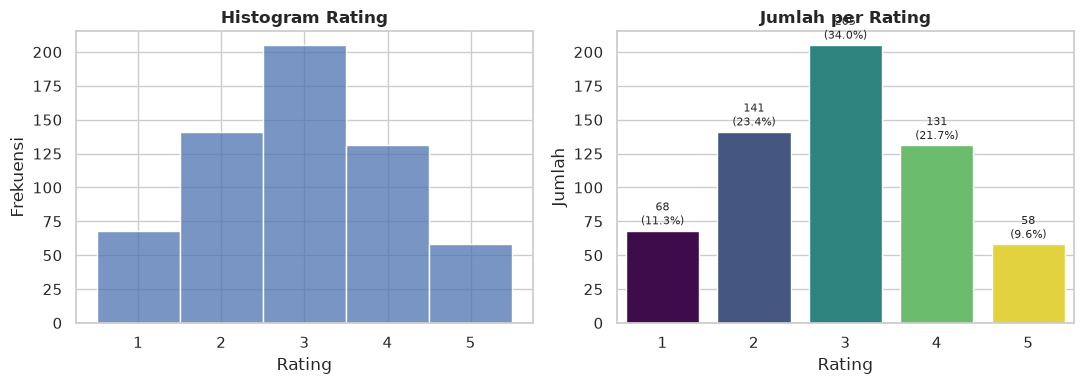

Rata-rata rating : 2.95
Median rating    : 3.0
Modus rating     : 3
Std deviasi      : 1.13


In [5]:
"""
Distribusi Rating
==================
"""

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
sns.histplot(df["rating"], bins=5, discrete=True, kde=False,
             color="#4C72B0", edgecolor="white", ax=axes[0])
axes[0].set_title("Histogram Rating", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Frekuensi")

# Count plot dengan persentase
rating_counts = df["rating"].value_counts().sort_index()
bars = sns.barplot(x=rating_counts.index, y=rating_counts.values,
                   hue=rating_counts.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Jumlah per Rating", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Jumlah")

for rect, val in zip(bars.patches, rating_counts.values):
    pct = val / len(df) * 100
    axes[1].text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2,
                 f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Ringkasan
print(f"Rata-rata rating : {df['rating'].mean():.2f}")
print(f"Median rating    : {df['rating'].median():.1f}")
print(f"Modus rating     : {df['rating'].mode()[0]}")
print(f"Std deviasi      : {df['rating'].std():.2f}")

## 👤 Rating per User

Berapa banyak item yang dirating oleh tiap user? Apakah ada user yang sangat aktif vs pasif?

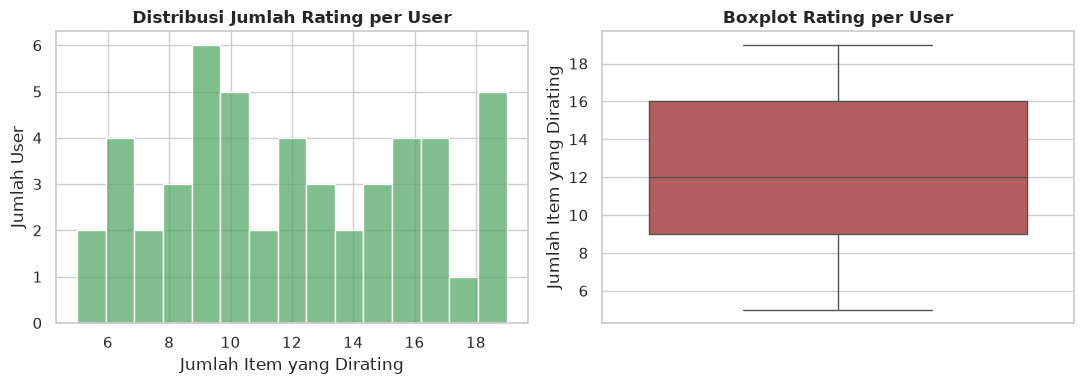

Rata-rata rating per user : 12.1
Min rating per user       : 5
Max rating per user       : 19
User paling aktif         : user_id=4 (19 item)
User paling pasif         : user_id=44 (5 item)


In [6]:
"""
Rating per User
================
"""

ratings_per_user = df.groupby("user_id")["item_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
sns.histplot(ratings_per_user, bins=15, color="#55A868", edgecolor="white", ax=axes[0])
axes[0].set_title("Distribusi Jumlah Rating per User", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah Item yang Dirating")
axes[0].set_ylabel("Jumlah User")

# Boxplot
sns.boxplot(y=ratings_per_user, color="#C44E52", ax=axes[1])
axes[1].set_title("Boxplot Rating per User", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Jumlah Item yang Dirating")

plt.tight_layout()
plt.show()

print(f"Rata-rata rating per user : {ratings_per_user.mean():.1f}")
print(f"Min rating per user       : {ratings_per_user.min()}")
print(f"Max rating per user       : {ratings_per_user.max()}")
print(f"User paling aktif         : user_id={ratings_per_user.idxmax()} ({ratings_per_user.max()} item)")
print(f"User paling pasif         : user_id={ratings_per_user.idxmin()} ({ratings_per_user.min()} item)")

## 📦 Rating per Item

Berapa banyak user yang merating tiap item? Item mana yang paling populer?

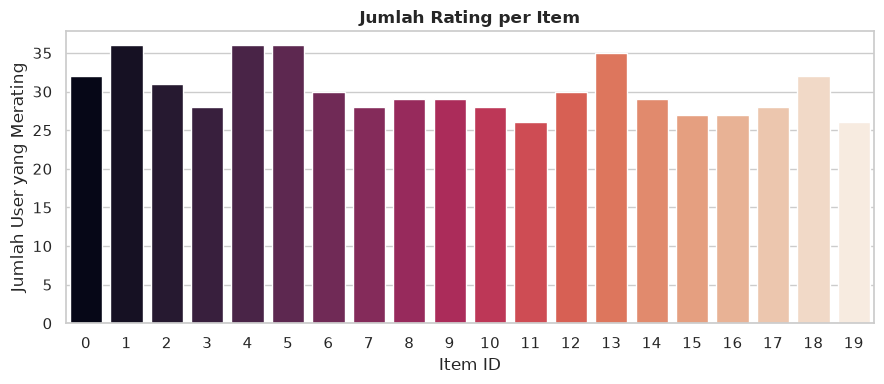

Rata-rata rating per item : 30.1
Item terpopuler           : item_id=1 (36 user)
Item paling jarang        : item_id=11 (26 user)


In [7]:
"""
Rating per Item
================
"""

ratings_per_item = df.groupby("item_id")["user_id"].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = sns.barplot(x=ratings_per_item.index, y=ratings_per_item.values,
                   hue=ratings_per_item.index, palette="rocket", legend=False, ax=ax)
ax.set_title("Jumlah Rating per Item", fontsize=12, fontweight="bold")
ax.set_xlabel("Item ID")
ax.set_ylabel("Jumlah User yang Merating")

plt.tight_layout()
plt.show()

print(f"Rata-rata rating per item : {ratings_per_item.mean():.1f}")
print(f"Item terpopuler           : item_id={ratings_per_item.idxmax()} ({ratings_per_item.max()} user)")
print(f"Item paling jarang        : item_id={ratings_per_item.idxmin()} ({ratings_per_item.min()} user)")

## 🕸️ Sparsity User-Item Matrix

Seberapa padat matriks user×item? Semakin jarang (sparse), semakin menantang untuk collaborative filtering.

Jumlah user      : 50
Jumlah item      : 20
Total sel        : 1000
Rating terisi    : 603
Densitas         : 60.30%
Sparsity         : 39.70%


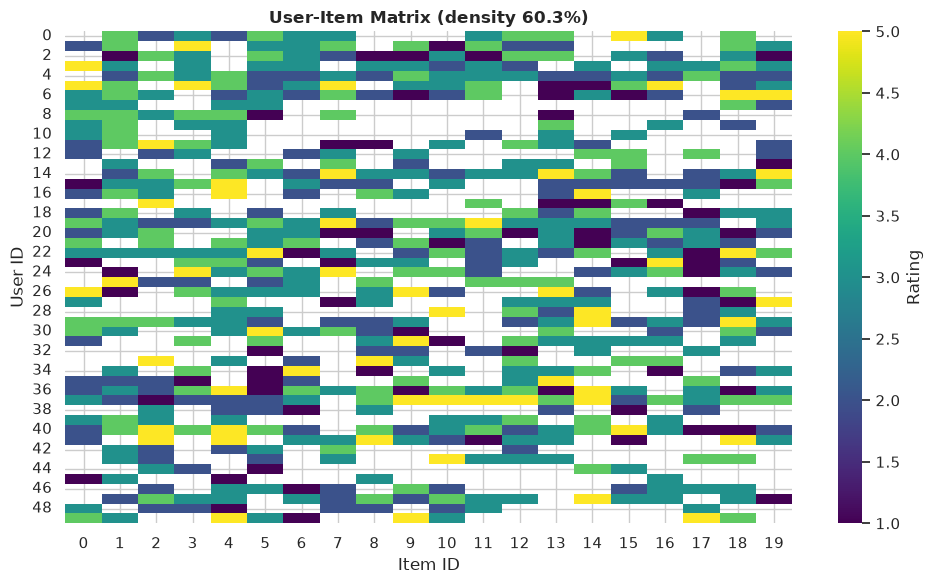

In [8]:
"""
Sparsity User-Item Matrix
===========================
"""

n_users = df["user_id"].nunique()
n_items = df["item_id"].nunique()
n_ratings = len(df)
density = n_ratings / (n_users * n_items) * 100
sparsity = 100 - density

print(f"Jumlah user      : {n_users}")
print(f"Jumlah item      : {n_items}")
print(f"Total sel        : {n_users * n_items}")
print(f"Rating terisi    : {n_ratings}")
print(f"Densitas         : {density:.2f}%")
print(f"Sparsity         : {sparsity:.2f}%")

# Visualisasi matriks user-item
matrix = df.pivot_table(index="user_id", columns="item_id", values="rating")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix, cmap="viridis", cbar_kws={"label": "Rating"},
            linewidths=0, ax=ax)
ax.set_title(f"User-Item Matrix (density {density:.1f}%)", fontsize=12, fontweight="bold")
ax.set_xlabel("Item ID")
ax.set_ylabel("User ID")
plt.tight_layout()
plt.show()

## 🏆 Item Terbaik & Terpopuler

Item dengan rating rata-rata tertinggi (dengan minimal jumlah rating) dan item terpopuler.

── Top 10 item terbaik (min 10 rating) ──


,Rata-rata,Jumlah Rating
item_id,,
3,3.29,28
4,3.25,36
14,3.24,29
2,3.16,31
1,3.11,36
12,3.10,30
9,3.07,29
11,3.04,26
18,3.03,32


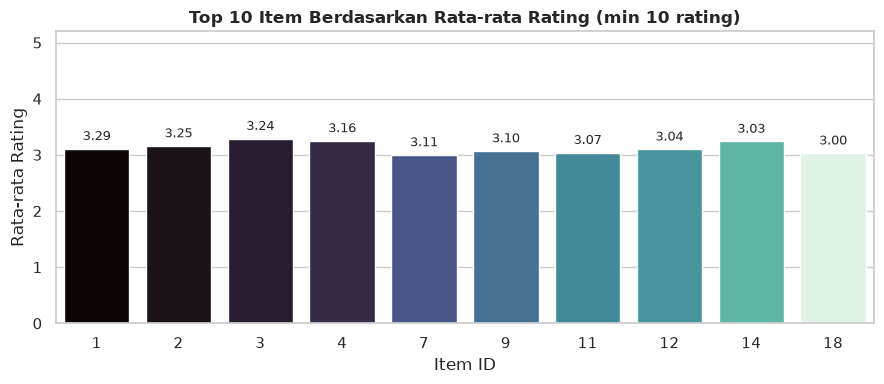

In [9]:
"""
Item Terbaik & Terpopuler
==========================
"""

item_stats = df.groupby("item_id")["rating"].agg(["mean", "count"]).round(2)
item_stats.columns = ["Rata-rata", "Jumlah Rating"]
item_stats = item_stats.sort_values("Rata-rata", ascending=False)

# Top 10 item dengan minimal 10 rating
MIN_RATINGS = 10
top_items = item_stats[item_stats["Jumlah Rating"] >= MIN_RATINGS].head(10)

print(f"── Top 10 item terbaik (min {MIN_RATINGS} rating) ──")
display(top_items)

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 4))
bars = sns.barplot(x=top_items.index, y=top_items["Rata-rata"],
                   hue=top_items.index, palette="mako", legend=False, ax=ax)
ax.set_title(f"Top 10 Item Berdasarkan Rata-rata Rating (min {MIN_RATINGS} rating)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Item ID")
ax.set_ylabel("Rata-rata Rating")
ax.set_ylim(0, 5.2)

for rect, val in zip(bars.patches, top_items["Rata-rata"]):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.1,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 🧠 Kesimpulan & Rekomendasi

Ringkasan temuan EDA dan langkah selanjutnya untuk pemodelan recommender.

In [10]:
"""
Kesimpulan & Rekomendasi
==========================
"""

top_item_id = top_items.index[0]
top_item_rating = top_items.iloc[0]["Rata-rata"]
most_popular_item = ratings_per_item.idxmax()
most_popular_count = ratings_per_item.max()

summary_lines = [
    f"1. **Data bersih** — {len(df)} rating, tidak ada nilai hilang, tipe data konsisten.",
    f"2. **Distribusi rating** — rata-rata {df['rating'].mean():.2f}, cenderung bias ke rating tinggi "
    f"(modus {df['rating'].mode()[0]}), umum pada data rating.",
    f"3. **Aktivitas user bervariasi** — rata-rata {ratings_per_user.mean():.1f} item/user, "
    f"ada user sangat aktif ({ratings_per_user.max()} item) dan pasif ({ratings_per_user.min()} item).",
    f"4. **Popularitas item tidak merata** — item terpopuler dirating {most_popular_count} user, "
    f"item paling jarang hanya {ratings_per_item.min()} user.",
    f"5. **Matriks sparse** — densitas hanya {density:.2f}% → tantangan utama collaborative filtering.",
    f"6. **Item terbaik** — item #{top_item_id} punya rata-rata {top_item_rating:.2f} "
    f"(min {MIN_RATINGS} rating).",
    f"7. **Data tetap** — dataset dari CSV memastikan hasil reproduksibel di semua environment.",
]

rec_lines = [
    "• **Model**: mulai dengan User-Based / Item-Based Collaborative Filtering (kNN).",
    "• **Alternatif**: Matrix Factorization (SVD / Funk SVD) untuk menangani sparsity.",
    "• **Evaluasi**: gunakan train/test split berbasis rating (bukan acak per baris).",
    "• **Metrik**: RMSE / MAE untuk prediksi rating, Precision@K untuk top-N recommendation.",
    "• **Cold-start**: item/user dengan sedikit rating perlu penanganan khusus (fallback ke popularitas).",
    "• **Reproduksibilitas**: selalu set seed & gunakan dataset tetap (CSV).",
]

print("=" * 70)
print("KESIMPULAN")
print("=" * 70)
for line in summary_lines:
    print(f"  {line}")
print()
print("=" * 70)
print("REKOMENDASI")
print("=" * 70)
for line in rec_lines:
    print(f"  {line}")

KESIMPULAN
  1. **Data bersih** — 603 rating, tidak ada nilai hilang, tipe data konsisten.
  2. **Distribusi rating** — rata-rata 2.95, cenderung bias ke rating tinggi (modus 3), umum pada data rating.
  3. **Aktivitas user bervariasi** — rata-rata 12.1 item/user, ada user sangat aktif (19 item) dan pasif (5 item).
  4. **Popularitas item tidak merata** — item terpopuler dirating 36 user, item paling jarang hanya 26 user.
  5. **Matriks sparse** — densitas hanya 60.30% → tantangan utama collaborative filtering.
  6. **Item terbaik** — item #3 punya rata-rata 3.29 (min 10 rating).
  7. **Data tetap** — dataset dari CSV memastikan hasil reproduksibel di semua environment.

REKOMENDASI
  • **Model**: mulai dengan User-Based / Item-Based Collaborative Filtering (kNN).
  • **Alternatif**: Matrix Factorization (SVD / Funk SVD) untuk menangani sparsity.
  • **Evaluasi**: gunakan train/test split berbasis rating (bukan acak per baris).
  • **Metrik**: RMSE / MAE untuk prediksi rating, Precisio